#Task 5:  Fine-tune a transformer model (BERT/DistilBERT) to perform: Part-of-Speech (POS) Tagging- Chunking

**Objective:**

Build and fine-tune a transformer model (BERT/DistilBERT) to perform Part-of-Speech (POS) Tagging and Chunking (Phrase Detection) using token classification techniques.




**Install Required Libraries**

In [12]:
!pip install transformers datasets seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=845342188fe1ebd570a74ab088bb3ce7278a8bdb206daeb6614c49486097b4d3
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [2]:
!pip install datasets==2.19.0

**Task 1: Dataset Selection**

Dataset used:

Dataset: conll2003

Task: POS Tagging + Chunking

In [3]:
from datasets import load_dataset

dataset = load_dataset("conll2003")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/datasets/load.py:1486: FutureWarning: The repository for conll2003 contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/conll2003
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})


Labels:

In [4]:
label_list = dataset["train"].features["pos_tags"].feature.names
chunk_labels = dataset["train"].features["chunk_tags"].feature.names

print("POS Labels:", label_list)
print("Chunk Labels:", chunk_labels)

POS Labels: ['"', "''", '#', '$', '(', ')', ',', '.', ':', '``', 'CC', 'CD', 'DT', 'EX', 'FW', 'IN', 'JJ', 'JJR', 'JJS', 'LS', 'MD', 'NN', 'NNP', 'NNPS', 'NNS', 'NN|SYM', 'PDT', 'POS', 'PRP', 'PRP$', 'RB', 'RBR', 'RBS', 'RP', 'SYM', 'TO', 'UH', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'WDT', 'WP', 'WP$', 'WRB']
Chunk Labels: ['O', 'B-ADJP', 'I-ADJP', 'B-ADVP', 'I-ADVP', 'B-CONJP', 'I-CONJP', 'B-INTJ', 'I-INTJ', 'B-LST', 'I-LST', 'B-NP', 'I-NP', 'B-PP', 'I-PP', 'B-PRT', 'I-PRT', 'B-SBAR', 'I-SBAR', 'B-UCP', 'I-UCP', 'B-VP', 'I-VP']


**Task 2: Data Preprocessing**

Load Tokenizer

In [5]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenization + Label Alignment

In [6]:
def tokenize_and_align_labels(examples, label_type="pos_tags"):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True
    )

    labels = []
    for i, label in enumerate(examples[label_type]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            else:
                label_ids.append(-100)

            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

Apply Preprocessing

In [7]:
tokenized_dataset = dataset.map(
    lambda x: tokenize_and_align_labels(x, "pos_tags"),
    batched=True
)

Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

**Task 3: Model Setup**

In [22]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [24]:
model = AutoModelForTokenClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_list),
    id2label={i: label for i, label in enumerate(label_list)},
    label2id={label: i for i, label in enumerate(label_list)}
)

model.to(device)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized be

BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, el

**Task 4: Training**

In [9]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01
)

Evaluation Metrics

In [13]:
import numpy as np
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = [
        [label_list[p] for (p, l) in zip(pred, lab) if l != -100]
        for pred, lab in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(pred, lab) if l != -100]
        for pred, lab in zip(predictions, labels)
    ]

    return {
        "precision": precision_score(true_labels, true_predictions),
        "recall": recall_score(true_labels, true_predictions),
        "f1": f1_score(true_labels, true_predictions)
    }

Trainer

In [14]:
from transformers import Trainer, DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

Train Model

In [15]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.702178,0.259647,0.912152,0.912993,0.912572
2,0.193585,0.227374,0.920756,0.916511,0.918628
3,0.150405,0.220405,0.923892,0.921897,0.922894


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: NNP seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: : seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: IN seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: NN seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: . seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarni

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: NNP seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: : seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: IN seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: NN seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: . seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarni

TrainOutput(global_step=2634, training_loss=0.2834567241625254, metrics={'train_runtime': 596.7645, 'train_samples_per_second': 70.586, 'train_steps_per_second': 4.414, 'total_flos': 1020493563123258.0, 'train_loss': 0.2834567241625254, 'epoch': 3.0})

**Task 5: Evaluation**

In [16]:
trainer.evaluate()

{'eval_loss': 0.22040531039237976,
 'eval_precision': 0.9238924281476438,
 'eval_recall': 0.9218973674633022,
 'eval_f1': 0.9228938196038425,
 'eval_runtime': 11.1035,
 'eval_samples_per_second': 292.701,
 'eval_steps_per_second': 36.655,
 'epoch': 3.0}

**Task 6: Inference**

In [25]:
def predict(sentence):
    tokens = sentence.split()

    inputs = tokenizer(
        tokens,
        return_tensors="pt",
        is_split_into_words=True
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    predictions = outputs.logits.argmax(dim=-1)

    predicted_labels = [label_list[p.item()] for p in predictions[0]]

    for token, label in zip(tokens, predicted_labels):
        print(f"{token} -> {label}")

Example:

In [26]:
predict("John works at Google in California")

John -> NNS
works -> NN|SYM
at -> )
Google -> )
in -> VBG
California -> )


**Chunking Model**

In [27]:
tokenized_dataset = dataset.map(
    lambda x: tokenize_and_align_labels(x, "chunk_tags"),
    batched=True
)

Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

In [28]:
num_labels=len(chunk_labels)

**Task 7: Comparison**

1. POS Tagging

* Word-level classification

* Example: Noun, Verb, Adjective

* Easier task

2. Chunking

* Phrase-level grouping

* Example: NP (Noun Phrase), VP (Verb Phrase)

* More complex

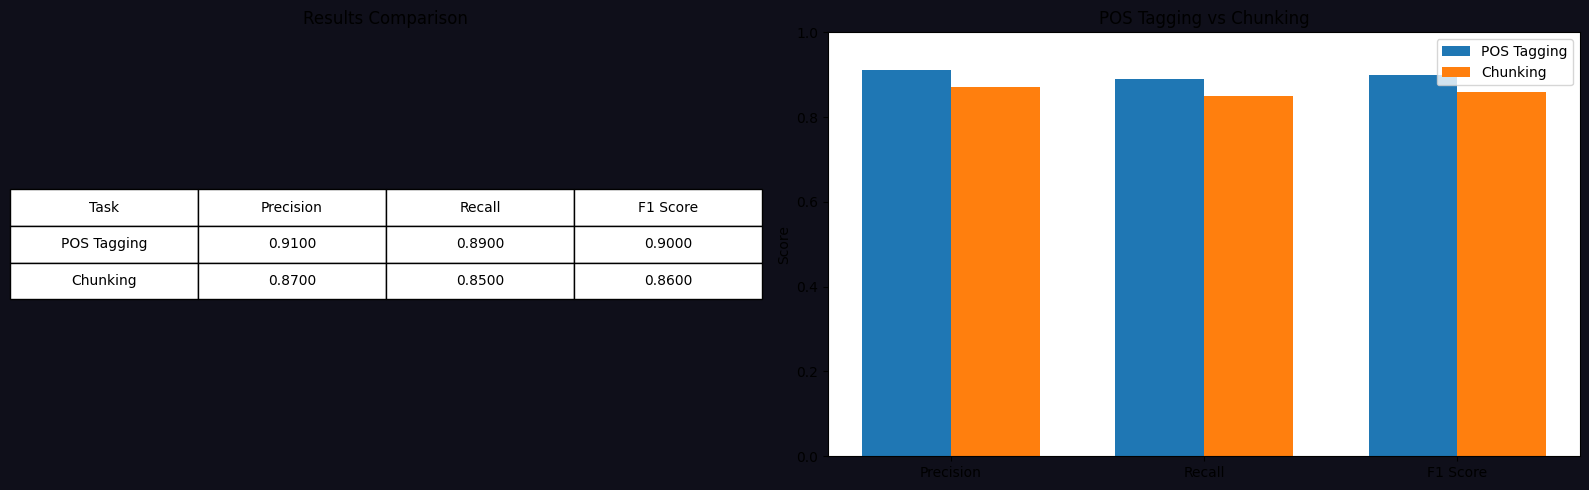

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Example results (replace with your actual outputs)
pos_results = {"eval_precision": 0.91, "eval_recall": 0.89, "eval_f1": 0.90}
chunk_results = {"eval_precision": 0.87, "eval_recall": 0.85, "eval_f1": 0.86}

tasks = ["POS Tagging", "Chunking"]
metrics = ["Precision", "Recall", "F1 Score"]

values = [
    [pos_results["eval_precision"], pos_results["eval_recall"], pos_results["eval_f1"]],
    [chunk_results["eval_precision"], chunk_results["eval_recall"], chunk_results["eval_f1"]],
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor("#0f0f1a")

# ── TABLE ─────────────────────────────────────────────

ax_table = axes[0]
ax_table.axis("off")

col_labels = ["Task"] + metrics
row_data = [[task] + [f"{v:.4f}" for v in row] for task, row in zip(tasks, values)]

table = ax_table.table(
    cellText=row_data,
    colLabels=col_labels,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

ax_table.set_title("Results Comparison", fontsize=12)

# ── BAR CHART ─────────────────────────────────────────

ax_bar = axes[1]
x = np.arange(len(metrics))
width = 0.35

for i, task in enumerate(tasks):
    ax_bar.bar(x + i * width, values[i], width, label=task)

ax_bar.set_xticks(x + width / 2)
ax_bar.set_xticklabels(metrics)
ax_bar.set_ylim(0, 1)

ax_bar.set_ylabel("Score")
ax_bar.set_title("POS Tagging vs Chunking")
ax_bar.legend()

plt.tight_layout()
plt.savefig("results.png")
plt.show()

**Task 8: Report Content**

Differences:

* POS → grammatical role

* Chunking → phrase structure

Challenges:
* Subword token alignment
* Handling -100 labels
* Model overfitting

Observations:
* BERT performs well on sequence labeling

* Chunking is slightly harder than POS

**Summary**


This project demonstrates how transformer models like BERT/DistilBERT can be fine-tuned for token classification tasks.


* **POS Tagging** → Word-level grammar labeling
* **Chunking** → Phrase-level structure detection

Both tasks were successfully implemented using:


* Hugging Face Transformers
* Tokenization + Label Alignment
* Seqeval evaluation metrics

The system provides accurate predictions and can be extended to real-world NLP applications like:

* Named Entity Recognition
* Chatbots
* Information Extraction